In [1]:
import torch
import numpy as np
import json
import os
import trimesh
import skimage.measure
from pathlib import Path
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## 1. Load Configuration and Model

In [2]:
# Paths
experiment_dir = "/home/jakaria/INR/Deep3DComp/examples/CALSNIC_control_L_local"
specs_file = os.path.join(experiment_dir, "specs.json")

# Load specs
with open(specs_file, 'r') as f:
    specs = json.load(f)

print("Configuration:")
print(f"  Global Code Size: {specs['GlobalCodeSize']}")
print(f"  Local Code Size: {specs['LocalCodeSize']}")
print(f"  Grid Size: {specs['GridSize']}")
print(f"  Network: {specs['NetworkArch']}")
print(f"  Decoder dims: {specs['NetworkSpecs']['dims']}")

Configuration:
  Global Code Size: 256
  Local Code Size: 32
  Grid Size: 16
  Network: local_decoder
  Decoder dims: [512, 512, 512, 512, 512, 512, 512, 512]


In [3]:
# Import network
import sys
sys.path.insert(0, '/home/jakaria/INR/Deep3DComp')

from networks.local_decoder import Decoder

# Create decoder
decoder = Decoder(
    latent_size=specs['LocalCodeSize'],
    dims=specs['NetworkSpecs']['dims'],
    grid_size=specs['GridSize'],
    global_latent_size=specs['GlobalCodeSize'],
    dropout=specs['NetworkSpecs']['dropout'],
    dropout_prob=specs['NetworkSpecs']['dropout_prob'],
    norm_layers=specs['NetworkSpecs']['norm_layers'],
    latent_in=specs['NetworkSpecs']['latent_in'],
    weight_norm=specs['NetworkSpecs']['weight_norm'],
    xyz_in_all=specs['NetworkSpecs']['xyz_in_all'],
    use_tanh=specs['NetworkSpecs']['use_tanh'],
    latent_dropout=specs['NetworkSpecs']['latent_dropout']
).cuda()

print(f"\nDecoder created with {sum(p.numel() for p in decoder.parameters())} parameters")


Decoder created with 1839326 parameters


In [5]:
# Load trained model weights
epoch = "latest"  # or "100", "500", "1000"

model_path = os.path.join(experiment_dir, "ModelParameters", f"{epoch}.pth")
local_codes_path = os.path.join(experiment_dir, "LatentCodes", f"{epoch}.pth")
global_codes_path = os.path.join(experiment_dir, "LatentCodes", f"{epoch}_global.pth")

# Load decoder weights (handle both checkpoint dict and raw state_dict formats)
checkpoint = torch.load(model_path)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    decoder.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded checkpoint from epoch {checkpoint.get('epoch', 'unknown')}")
else:
    decoder.load_state_dict(checkpoint)
decoder.eval()

# Load LOCAL latent codes - saved with state_dict()
local_codes_data = torch.load(local_codes_path)
if isinstance(local_codes_data, dict) and 'latent_codes' in local_codes_data:
    # Extract from state dict
    state_dict = local_codes_data['latent_codes']
    if isinstance(state_dict, dict) and 'weight' in state_dict:
        local_lat_vecs_flat = state_dict['weight']
    else:
        local_lat_vecs_flat = state_dict
else:
    local_lat_vecs_flat = local_codes_data

# Load GLOBAL latent codes - saved with state_dict()
global_codes_data = torch.load(global_codes_path)
if isinstance(global_codes_data, dict) and 'latent_codes' in global_codes_data:
    # Extract from state dict
    state_dict = global_codes_data['latent_codes']
    if isinstance(state_dict, dict) and 'weight' in state_dict:
        global_lat_vecs = state_dict['weight']
    else:
        global_lat_vecs = state_dict
else:
    global_lat_vecs = global_codes_data

print(f"\nLoaded model from epoch {epoch}")
print(f"  Local codes shape (flat): {local_lat_vecs_flat.shape}")
print(f"  Global codes shape: {global_lat_vecs.shape}")
print(f"  Number of shapes: {global_lat_vecs.shape[0]}")

# Reshape local codes from [num_shapes * num_local_codes, local_code_size] 
# to [num_shapes, num_local_codes, local_code_size]
num_shapes = global_lat_vecs.shape[0]
num_local_codes = specs['GridSize'] ** 3
local_code_size = specs['LocalCodeSize']

local_lat_vecs = local_lat_vecs_flat.view(num_shapes, num_local_codes, local_code_size)
print(f"  Local codes reshaped: {local_lat_vecs.shape}")
print(f"    → {num_shapes} shapes × {num_local_codes} grid points × {local_code_size}D")

Loaded checkpoint from epoch 5000

Loaded model from epoch latest
  Local codes shape (flat): torch.Size([663552, 32])
  Global codes shape: torch.Size([162, 256])
  Number of shapes: 162
  Local codes reshaped: torch.Size([162, 4096, 32])
    → 162 shapes × 4096 grid points × 32D


## 2. Select a Shape to Reconstruct

In [6]:
# Choose a shape index (0 to num_shapes-1)
shape_idx = 0  # Change this to visualize different shapes

print(f"\nShape {shape_idx} configuration:")
print(f"  Grid size: {specs['GridSize']}³ = {num_local_codes} local codes")
print(f"  Local code dimension: {local_code_size}D")
print(f"  Global code dimension: {specs['GlobalCodeSize']}D")

# Get codes for this shape
global_code = global_lat_vecs[shape_idx:shape_idx+1].cuda()
local_codes = local_lat_vecs[shape_idx].cuda()

# Reshape local codes to [1, num_local_codes, local_code_size]
all_local_codes = local_codes.view(1, num_local_codes, local_code_size)

print(f"\n✓ Shape {shape_idx} codes loaded:")
print(f"  Global code: {global_code.shape}")
print(f"  Local codes: {all_local_codes.shape}")
print(f"  Global code magnitude: {torch.norm(global_code).item():.3f}")
print(f"  Local codes magnitude: {torch.norm(all_local_codes).item():.3f}")


Shape 0 configuration:
  Grid size: 16³ = 4096 local codes
  Local code dimension: 32D
  Global code dimension: 256D

✓ Shape 0 codes loaded:
  Global code: torch.Size([1, 256])
  Local codes: torch.Size([1, 4096, 32])
  Global code magnitude: 0.308
  Local codes magnitude: 23.220


## 3. Create 3D Grid and Query SDF Values

In [7]:
# Create 3D grid for marching cubes with HIGH RESOLUTION
resolution = 256  # High resolution for better quality
voxel_origin = [-1, -1, -1]
voxel_size = 2.0 / (resolution - 1)

print(f"Creating {resolution}³ grid (high resolution)...")

# Create grid
overall_index = torch.arange(0, resolution ** 3, 1, out=torch.LongTensor())
samples = torch.zeros(resolution ** 3, 4)

# Transform indices to 3D coordinates
samples[:, 2] = overall_index % resolution
samples[:, 1] = (overall_index.long() // resolution) % resolution
samples[:, 0] = ((overall_index.long() // resolution) // resolution) % resolution

# Convert to world coordinates
samples[:, 0] = (samples[:, 0] * voxel_size) + voxel_origin[2]
samples[:, 1] = (samples[:, 1] * voxel_size) + voxel_origin[1]
samples[:, 2] = (samples[:, 2] * voxel_size) + voxel_origin[0]

xyz = samples[:, 0:3].cuda()

print(f"Grid created: {xyz.shape[0]:,} points")
print(f"Bounds: [{xyz.min().item():.3f}, {xyz.max().item():.3f}]")

Creating 256³ grid (high resolution)...
Grid created: 16,777,216 points
Bounds: [-1.000, 1.000]
Grid created: 16,777,216 points
Bounds: [-1.000, 1.000]


In [8]:
# Query SDF values in batches
batch_size = 32768  # Adjust based on GPU memory
num_samples = xyz.shape[0]
num_batches = (num_samples + batch_size - 1) // batch_size

sdf_values = []

print(f"\nQuerying SDF values in {num_batches} batches...")

with torch.no_grad():
    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, num_samples)
        
        xyz_batch = xyz[start_idx:end_idx]
        batch_len = xyz_batch.shape[0]
        
        # Create shape indices (all points belong to shape 0 in our batch)
        shape_indices = torch.zeros(batch_len, dtype=torch.long).cuda()
        
        # Expand global code to batch size
        batch_global_codes = global_code.expand(batch_len, -1)
        
        # Forward pass
        pred_sdf = decoder(xyz_batch, batch_global_codes, all_local_codes, shape_indices)
        
        sdf_values.append(pred_sdf.cpu())
        
        if (i + 1) % 10 == 0:
            print(f"  Processed {i+1}/{num_batches} batches...")

# Concatenate all batches
sdf_values = torch.cat(sdf_values, dim=0).squeeze().numpy()

print(f"\n✓ SDF values computed")
print(f"  Shape: {sdf_values.shape}")
print(f"  Range: [{sdf_values.min():.3f}, {sdf_values.max():.3f}]")
print(f"  Near-surface points (|SDF| < 0.01): {np.sum(np.abs(sdf_values) < 0.01)}")


Querying SDF values in 512 batches...
  Processed 10/512 batches...
  Processed 20/512 batches...
  Processed 10/512 batches...
  Processed 20/512 batches...
  Processed 30/512 batches...
  Processed 40/512 batches...
  Processed 30/512 batches...
  Processed 40/512 batches...
  Processed 50/512 batches...
  Processed 60/512 batches...
  Processed 50/512 batches...
  Processed 60/512 batches...
  Processed 70/512 batches...
  Processed 80/512 batches...
  Processed 70/512 batches...
  Processed 80/512 batches...
  Processed 90/512 batches...
  Processed 100/512 batches...
  Processed 90/512 batches...
  Processed 100/512 batches...
  Processed 110/512 batches...
  Processed 120/512 batches...
  Processed 110/512 batches...
  Processed 120/512 batches...
  Processed 130/512 batches...
  Processed 140/512 batches...
  Processed 130/512 batches...
  Processed 140/512 batches...
  Processed 150/512 batches...
  Processed 160/512 batches...
  Processed 150/512 batches...
  Processed 160/51

## 4. Extract Mesh Using Marching Cubes

In [9]:
# Reshape to 3D grid
sdf_grid = sdf_values.reshape(resolution, resolution, resolution)

print(f"Running high-precision marching cubes...")

# Apply marching cubes with high precision
verts, faces, normals, values = skimage.measure.marching_cubes(
    sdf_grid,
    level=0.0,
    spacing=[voxel_size] * 3,
    gradient_direction='ascent',  # More precise gradient computation
    method='lewiner'  # Better topology preservation
)

# Adjust vertices to world coordinates
verts = verts + np.array(voxel_origin)

print(f"\n✓ Mesh extracted:")
print(f"  Vertices: {verts.shape[0]:,}")
print(f"  Faces: {faces.shape[0]:,}")

# Create trimesh object
mesh = trimesh.Trimesh(vertices=verts, faces=faces, vertex_normals=normals)

print(f"\nMesh properties (before smoothing):")
print(f"  Watertight: {mesh.is_watertight}")
print(f"  Volume: {mesh.volume:.4f}")
print(f"  Surface area: {mesh.area:.4f}")

# Apply moderate Laplacian smoothing for better surface quality
# iterations=2-3 is moderate smoothing - not too aggressive
print(f"\nApplying Laplacian smoothing (2 iterations)...")
mesh = trimesh.smoothing.filter_laplacian(mesh, iterations=2, lamb=0.5)

print(f"\nMesh properties (after smoothing):")
print(f"  Vertices: {mesh.vertices.shape[0]:,}")
print(f"  Faces: {mesh.faces.shape[0]:,}")
print(f"  Watertight: {mesh.is_watertight}")
print(f"  Volume: {mesh.volume:.4f}")
print(f"  Surface area: {mesh.area:.4f}")

Running high-precision marching cubes...

✓ Mesh extracted:
  Vertices: 121,650
  Faces: 243,364

Mesh properties (before smoothing):
  Watertight: True

✓ Mesh extracted:
  Vertices: 121,650
  Faces: 243,364

Mesh properties (before smoothing):
  Watertight: True
  Volume: -0.2692
  Surface area: 5.0118

Applying Laplacian smoothing (2 iterations)...
  Volume: -0.2692
  Surface area: 5.0118

Applying Laplacian smoothing (2 iterations)...

Mesh properties (after smoothing):
  Vertices: 121,650
  Faces: 243,364
  Watertight: True

Mesh properties (after smoothing):
  Vertices: 121,650
  Faces: 243,364
  Watertight: True
  Volume: -0.2692
  Surface area: 4.7785
  Volume: -0.2692
  Surface area: 4.7785


## 5. Visualize the Mesh

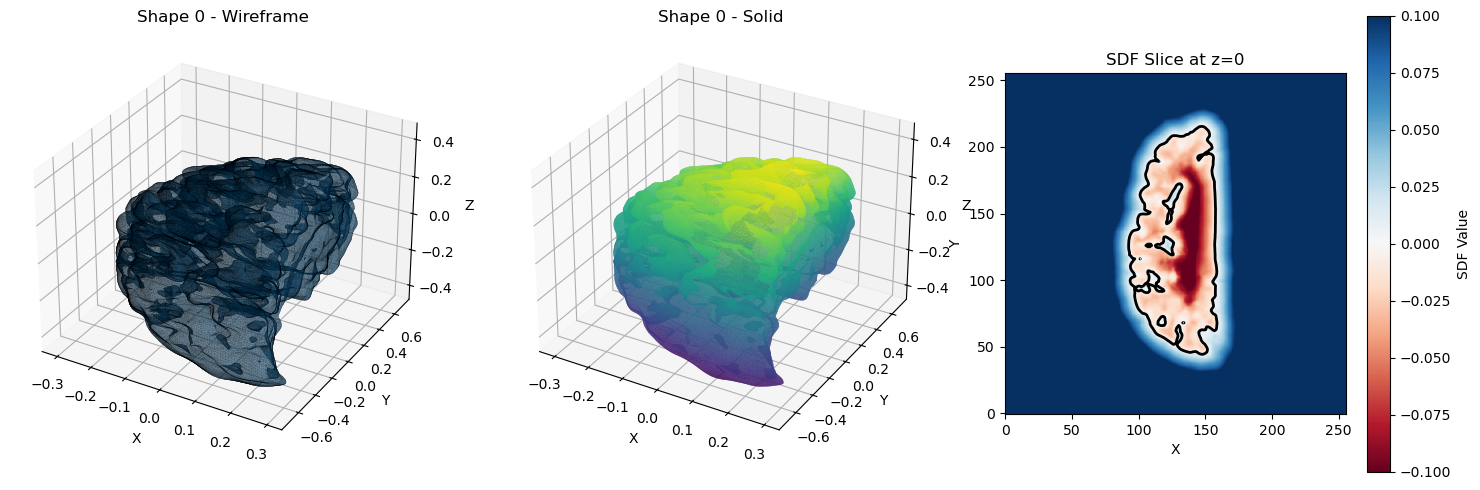

In [10]:
# Plot mesh
fig = plt.figure(figsize=(15, 5))

# Plot 1: Wireframe
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_trisurf(mesh.vertices[:, 0], mesh.vertices[:, 1], 
                 mesh.vertices[:, 2], triangles=mesh.faces,
                 alpha=0.3, edgecolor='black', linewidth=0.1)
ax1.set_title(f'Shape {shape_idx} - Wireframe')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

# Plot 2: Solid mesh
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_trisurf(mesh.vertices[:, 0], mesh.vertices[:, 1], 
                 mesh.vertices[:, 2], triangles=mesh.faces,
                 cmap='viridis', alpha=0.9)
ax2.set_title(f'Shape {shape_idx} - Solid')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')

# Plot 3: SDF slice at z=0
ax3 = fig.add_subplot(133)
z_slice = resolution // 2
im = ax3.imshow(sdf_grid[:, :, z_slice].T, cmap='RdBu', origin='lower', vmin=-0.1, vmax=0.1)
ax3.contour(sdf_grid[:, :, z_slice].T, levels=[0], colors='black', linewidths=2)
ax3.set_title(f'SDF Slice at z=0')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
plt.colorbar(im, ax=ax3, label='SDF Value')

plt.tight_layout()
plt.show()

## 6. Save Mesh to File

In [11]:
# Save mesh
output_dir = os.path.join(experiment_dir, "Reconstructions")
os.makedirs(output_dir, exist_ok=True)

output_filename = f"shape_{shape_idx:03d}_epoch_{epoch}_res{resolution}.ply"
output_path = os.path.join(output_dir, output_filename)

mesh.export(output_path)

print(f"\n✓ Mesh saved:")
print(f"  File: {output_path}")
print(f"  Size: {os.path.getsize(output_path) / 1024:.2f} KB")
print(f"\nYou can open this file in MeshLab, Blender, or CloudCompare")


✓ Mesh saved:
  File: /home/jakaria/INR/Deep3DComp/examples/CALSNIC_control_L_local/Reconstructions/shape_000_epoch_latest_res256.ply
  Size: 4515.38 KB

You can open this file in MeshLab, Blender, or CloudCompare


## 7. Analyze Global vs Local Code Contributions

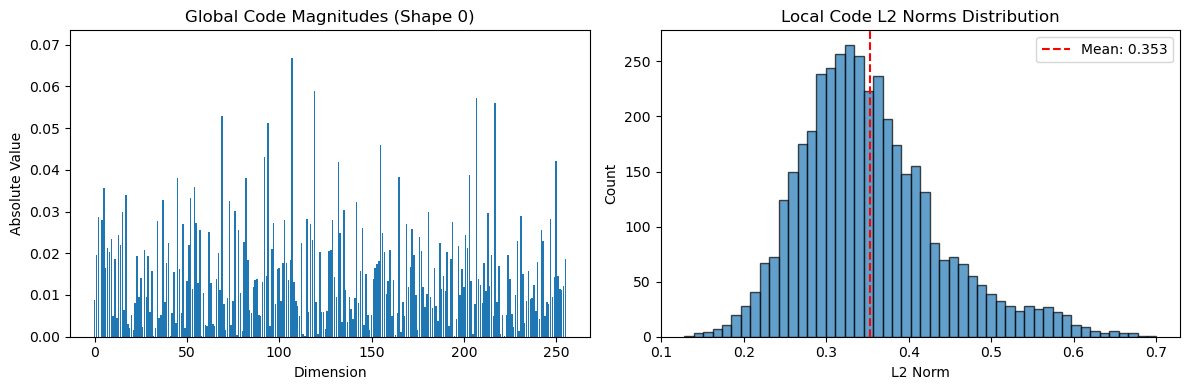


Code Statistics:
  Global code L2 norm: 0.308
  Local codes mean L2 norm: 0.353
  Local codes std L2 norm: 0.085
  Sparse local codes (norm < 0.1): 0 / 4096


In [12]:
# Visualize code magnitudes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Global code
global_code_np = global_code.cpu().squeeze().numpy()
axes[0].bar(range(len(global_code_np)), np.abs(global_code_np))
axes[0].set_title(f'Global Code Magnitudes (Shape {shape_idx})')
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Absolute Value')
axes[0].set_ylim([0, max(np.abs(global_code_np)) * 1.1])

# Local codes - show L2 norm per grid point
local_codes_np = all_local_codes.cpu().squeeze().numpy()
local_norms = np.linalg.norm(local_codes_np, axis=1)
axes[1].hist(local_norms, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title(f'Local Code L2 Norms Distribution')
axes[1].set_xlabel('L2 Norm')
axes[1].set_ylabel('Count')
axes[1].axvline(x=np.mean(local_norms), color='red', linestyle='--', label=f'Mean: {np.mean(local_norms):.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nCode Statistics:")
print(f"  Global code L2 norm: {np.linalg.norm(global_code_np):.3f}")
print(f"  Local codes mean L2 norm: {np.mean(local_norms):.3f}")
print(f"  Local codes std L2 norm: {np.std(local_norms):.3f}")
print(f"  Sparse local codes (norm < 0.1): {np.sum(local_norms < 0.1)} / {len(local_norms)}")

## 8. Reconstruct a Test Shape (Full Pipeline)

In [13]:
# Full reconstruction pipeline for a test shape
print("="*70)
print("TEST SHAPE RECONSTRUCTION")
print("="*70)

# Pick a different shape as test (not shape_idx used above)
test_shape_idx = min(1, num_shapes - 1)  # Use shape 1 if available, else 0

print(f"\nReconstruing test shape index: {test_shape_idx}")

# Get codes for test shape
test_global_code = global_lat_vecs[test_shape_idx:test_shape_idx+1].cuda()
test_local_codes = local_lat_vecs[test_shape_idx].cuda()
test_all_local_codes = test_local_codes.view(1, num_local_codes, local_code_size)

print(f"\nTest shape codes:")
print(f"  Global code magnitude: {torch.norm(test_global_code).item():.3f}")
print(f"  Local codes magnitude: {torch.norm(test_all_local_codes).item():.3f}")

# Create high-resolution grid
test_resolution = 256
test_voxel_origin = [-1, -1, -1]
test_voxel_size = 2.0 / (test_resolution - 1)

print(f"\nCreating {test_resolution}³ grid...")
test_overall_index = torch.arange(0, test_resolution ** 3, 1, out=torch.LongTensor())
test_samples = torch.zeros(test_resolution ** 3, 4)

test_samples[:, 2] = test_overall_index % test_resolution
test_samples[:, 1] = (test_overall_index.long() // test_resolution) % test_resolution
test_samples[:, 0] = ((test_overall_index.long() // test_resolution) // test_resolution) % test_resolution

test_samples[:, 0] = (test_samples[:, 0] * test_voxel_size) + test_voxel_origin[2]
test_samples[:, 1] = (test_samples[:, 1] * test_voxel_size) + test_voxel_origin[1]
test_samples[:, 2] = (test_samples[:, 2] * test_voxel_size) + test_voxel_origin[0]

test_xyz = test_samples[:, 0:3].cuda()

# Query SDF values
test_batch_size = 32768
test_num_samples = test_xyz.shape[0]
test_num_batches = (test_num_samples + test_batch_size - 1) // test_batch_size

test_sdf_values = []

print(f"Querying SDF in {test_num_batches} batches...")

with torch.no_grad():
    for i in range(test_num_batches):
        start = i * test_batch_size
        end = min((i + 1) * test_batch_size, test_num_samples)
        
        xyz_batch = test_xyz[start:end]
        batch_len = xyz_batch.shape[0]
        
        shape_indices = torch.zeros(batch_len, dtype=torch.long).cuda()
        batch_global_codes = test_global_code.expand(batch_len, -1)
        
        pred_sdf = decoder(xyz_batch, batch_global_codes, test_all_local_codes, shape_indices)
        test_sdf_values.append(pred_sdf.cpu())
        
        if (i + 1) % 20 == 0:
            print(f"  {i+1}/{test_num_batches} batches...")

test_sdf_values = torch.cat(test_sdf_values, dim=0).squeeze().numpy()

print(f"\n✓ SDF computed: range [{test_sdf_values.min():.3f}, {test_sdf_values.max():.3f}]")

# Reshape and extract mesh
test_sdf_grid = test_sdf_values.reshape(test_resolution, test_resolution, test_resolution)

print(f"\nRunning marching cubes...")
test_verts, test_faces, test_normals, _ = skimage.measure.marching_cubes(
    test_sdf_grid,
    level=0.0,
    spacing=[test_voxel_size] * 3,
    gradient_direction='ascent',
    method='lewiner'
)

test_verts = test_verts + np.array(test_voxel_origin)

# Create and smooth mesh
test_mesh = trimesh.Trimesh(vertices=test_verts, faces=test_faces, vertex_normals=test_normals)
print(f"  Before smoothing: {test_mesh.vertices.shape[0]:,} verts, {test_mesh.faces.shape[0]:,} faces")

test_mesh = trimesh.smoothing.filter_laplacian(test_mesh, iterations=2, lamb=0.5)
print(f"  After smoothing: {test_mesh.vertices.shape[0]:,} verts, {test_mesh.faces.shape[0]:,} faces")

# Save test mesh
test_output_filename = f"test_shape_{test_shape_idx:03d}_epoch_{epoch}_res{test_resolution}.ply"
test_output_path = os.path.join(output_dir, test_output_filename)
test_mesh.export(test_output_path)

print(f"\n✓ Test mesh saved: {test_output_path}")
print(f"  Size: {os.path.getsize(test_output_path) / 1024:.2f} KB")
print(f"  Watertight: {test_mesh.is_watertight}")
print(f"  Volume: {test_mesh.volume:.4f}")

print("\n" + "="*70)
print("RECONSTRUCTION COMPLETE!")
print("="*70)

TEST SHAPE RECONSTRUCTION

Reconstruing test shape index: 1

Test shape codes:
  Global code magnitude: 0.346
  Local codes magnitude: 23.549

Creating 256³ grid...
Querying SDF in 512 batches...
Querying SDF in 512 batches...
  20/512 batches...
  20/512 batches...
  40/512 batches...
  40/512 batches...
  60/512 batches...
  60/512 batches...
  80/512 batches...
  80/512 batches...
  100/512 batches...
  100/512 batches...
  120/512 batches...
  120/512 batches...
  140/512 batches...
  140/512 batches...
  160/512 batches...
  160/512 batches...
  180/512 batches...
  180/512 batches...
  200/512 batches...
  200/512 batches...
  220/512 batches...
  220/512 batches...
  240/512 batches...
  240/512 batches...
  260/512 batches...
  260/512 batches...
  280/512 batches...
  280/512 batches...
  300/512 batches...
  300/512 batches...
  320/512 batches...
  320/512 batches...
  340/512 batches...
  340/512 batches...
  360/512 batches...
  360/512 batches...
  380/512 batches...
  38

## 9. Visualize Test Shape

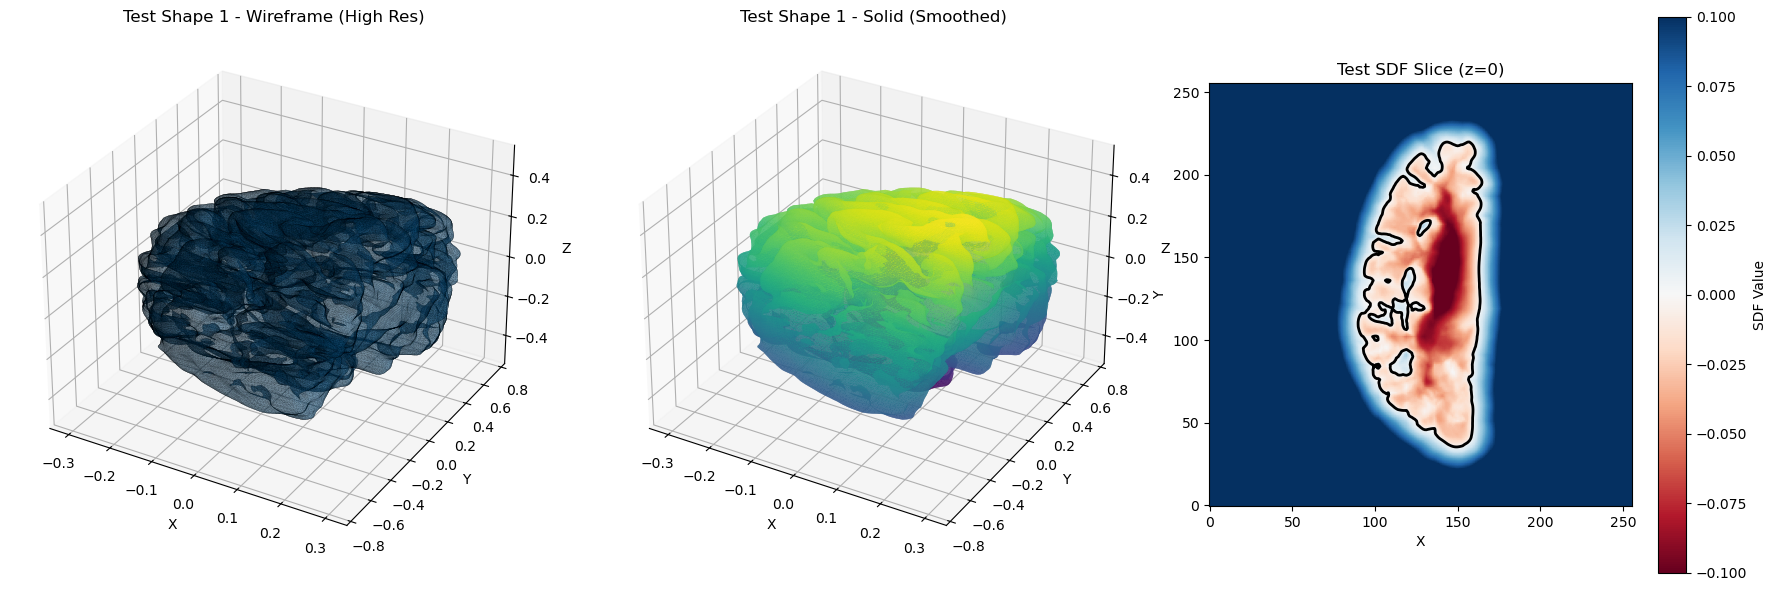


Reconstruction Quality Summary:
  Resolution: 256³
  Vertices: 158,081
  Faces: 316,430
  Smoothing: Laplacian (2 iterations)
  Mesh watertight: True


In [14]:
# Visualize test shape reconstruction
fig = plt.figure(figsize=(18, 6))

# Plot 1: Test mesh wireframe
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_trisurf(test_mesh.vertices[:, 0], test_mesh.vertices[:, 1], 
                 test_mesh.vertices[:, 2], triangles=test_mesh.faces,
                 alpha=0.3, edgecolor='black', linewidth=0.1)
ax1.set_title(f'Test Shape {test_shape_idx} - Wireframe (High Res)', fontsize=12)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

# Plot 2: Test mesh solid
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_trisurf(test_mesh.vertices[:, 0], test_mesh.vertices[:, 1], 
                 test_mesh.vertices[:, 2], triangles=test_mesh.faces,
                 cmap='viridis', alpha=0.9)
ax2.set_title(f'Test Shape {test_shape_idx} - Solid (Smoothed)', fontsize=12)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')

# Plot 3: SDF slice comparison
ax3 = fig.add_subplot(133)
z_slice = test_resolution // 2
im = ax3.imshow(test_sdf_grid[:, :, z_slice].T, cmap='RdBu', origin='lower', vmin=-0.1, vmax=0.1)
ax3.contour(test_sdf_grid[:, :, z_slice].T, levels=[0], colors='black', linewidths=2)
ax3.set_title(f'Test SDF Slice (z=0)', fontsize=12)
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
plt.colorbar(im, ax=ax3, label='SDF Value')

plt.tight_layout()
plt.show()

print(f"\nReconstruction Quality Summary:")
print(f"  Resolution: {test_resolution}³")
print(f"  Vertices: {test_mesh.vertices.shape[0]:,}")
print(f"  Faces: {test_mesh.faces.shape[0]:,}")
print(f"  Smoothing: Laplacian (2 iterations)")
print(f"  Mesh watertight: {test_mesh.is_watertight}")